# Proyecto: Análisis de mercado inmobiliario

En este proyecto se trabajará con un dataset de propiedades en venta publicado en el portal [Properati](www.properati.com.ar).

## Problema

Recientemente te has incorporado al equipo de Datos de una gran inmobiliaria. La primera tarea que se te asigna es ayudar a los tasadores/as a valuar las propiedades, ya que es un proceso difícil y, a veces, subjetivo. Para ello, propones crear un modelo de Machine Learning que, dadas ciertas características de la propiedad, prediga su precio de venta.

### 1. Pensando como un/a Data Scientist

¿Qué datos crees que te ayudarían a trabajar en el problema? ¿Por qué?

Para el analisis del precio de una propiedad considero necesario datos que permitan conocer la caracteristicas que pueden aumentar el valor del inmueble tales como el área, el tipo de propiedad y el número de alcobas y de baños, ademas de datos que permitan reconocer el lugar en el que se encuentra ya que los precios dependen del lugar en el que este localizado. Otros factores a tener en cuenta podria ser la fecha en la que se pone en venta el inmueble, esto debido a que hay posibilidades de que dependiendo de la epoca las dinamicas economicas del sector sean diferentes y por lo tanto varie el precio entre fechas.

### 2. Análisis Exploratorio de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
im=pd.read_csv('DS_Proyecto_01_Datos_Properati.csv')

In [3]:
im.head()

,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type
0,2019-10-17,2019-12-23,2019-10-17,-34.605880,-58.384949,Argentina,Capital Federal,San Cristobal,7.0,7.0,2.0,140.0,140.0,153000.0,USD,"***Venta semipiso centro, ideal hostel*****",DESCRIPCION DE LA PROPIEDAD: Departamento de 1...,Departamento,Venta
1,2019-10-17,2019-11-21,2019-10-17,-34.624056,-58.412110,Argentina,Capital Federal,Boedo,2.0,1.0,2.0,70.0,58.0,159000.0,USD,Espectacular PH reciclado en Boedo sin expensas.,PH reciclado en Boedo a una cuadra de la plaz...,PH,Venta
2,2019-10-17,2019-11-01,2019-10-17,-34.593569,-58.427474,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,45.0,45.0,125000.0,USD,Depto.tipo casa de 2 ambientes en Venta en Pal...,"2 ambienets amplio , excelente estado , patio ...",PH,Venta
3,2019-10-17,2019-12-23,2019-10-17,-34.581294,-58.436754,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,85.0,50.0,295000.0,USD,COSTA RICA 5800 / PALERMO HOLLYWOOD / VENTA PH...,HERMOSO PH EN PALERMO!!!2 AMBIENTES TOTALMENTE...,PH,Venta
4,2019-10-17,2020-03-11,2019-10-17,-34.914194,-57.938219,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,2.0,1.0,1.0,50.0,35.0,40000.0,USD,58 entre 1 y 2 Venta de departamento en ph.1 ...,58 entre 1 y 2 Venta de departamento en PH. P...,PH,Venta


Como se muestra, el data frame cuenta con columnas que representan la fecha de registro de la propiedad, posicion geografica y las caracteristicas tales como cantidad de baños, habitaciones y salones, ademas del área total y cubierta, el precio, tipo de moneda, tipo de propiedad, titulo y descripción de esta.

##### Datos faltantes

In [4]:
vfaltante=im.isna()
vfaltante.sum()

start_date             0
end_date               0
created_on             0
lat                 9925
lon                 9959
l1                     0
l2                     0
l3                     0
rooms                  0
bedrooms               0
bathrooms           5957
surface_total      20527
surface_covered    21614
price                  0
currency               0
title                  0
description            0
property_type          0
operation_type         0
dtype: int64

Hay una gran cantidad de datos faltantes para la latitud, longitud, baños, área total y cubierta de la propiedad.

##### Tipo de propiedades

A continuación se muestra un histograma de tipo de propiedades en el data frame. 

Tipos de propiedad : 10


Text(0, 0.5, 'Cantidad')

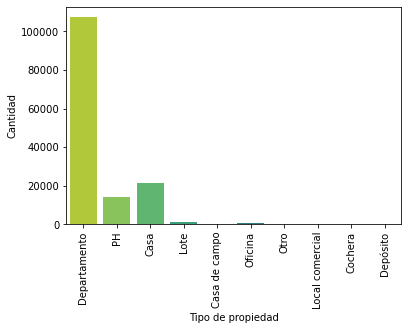

In [5]:
n = len(im['property_type'].unique())
print("Tipos de propiedad :", n)

sns.countplot(x="property_type",data=im, palette="viridis_r")
plt.xticks(rotation=90)
plt.xlabel("Tipo de propiedad")
plt.ylabel("Cantidad")

De este se concluye que hay 10 tipos de propiedades en el data frame y que la mayoria de estas son departamentos. Sin embargo a continuación miraremos la cantidad exacta de entradas por propiedad:

In [6]:
tipo=['Departamento','PH','Casa','Lote','Casa de Campo','Oficina','Otro','Local Comercial','Cochera','Depósito']
aa=[]
for i in tipo:
    a=im['property_type'].str.fullmatch(i)
    aa.append(a.sum())
s=0
for i in range(0,9):
    print(tipo[i],'=',aa[i])

Departamento = 107326
PH = 14298
Casa = 21521
Lote = 1312
Casa de Campo = 0
Oficina = 658
Otro = 374
Local Comercial = 0
Cochera = 259


Esto confirma lo observado en el histograma, además de eso ahora sabemos que no hay entradas para propiedades del tipo Casa de Campo o Local Comercial.

##### Propiedades por barrio y región

Se prodece a identificar la cantidad de inmuebles por barrio y región.

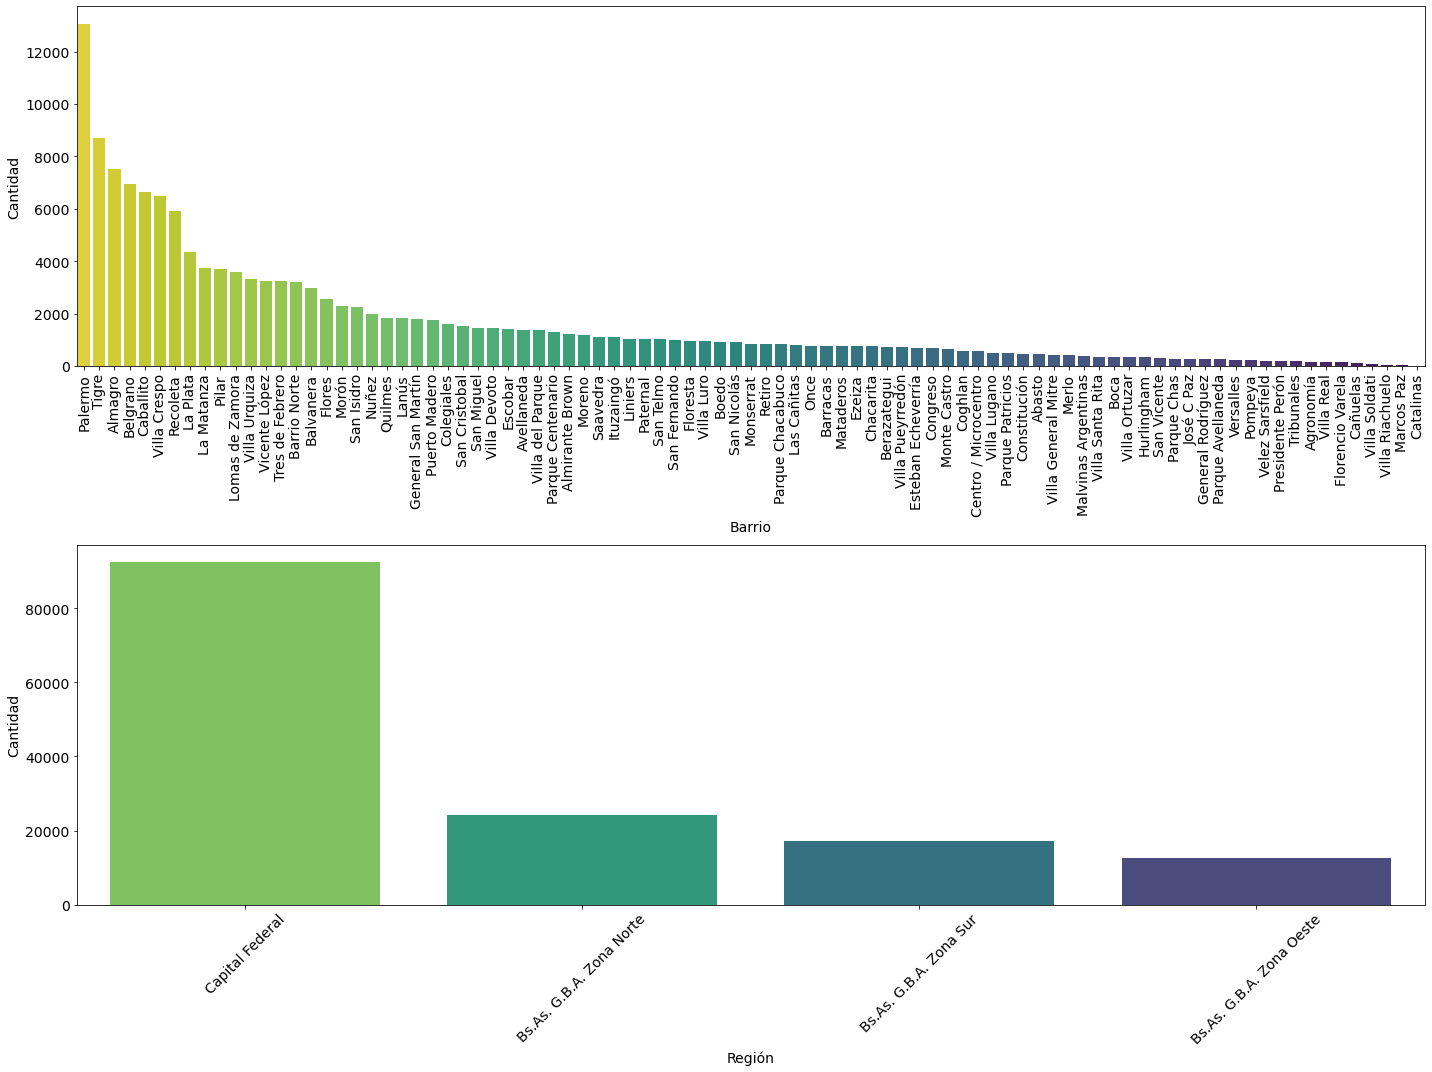

In [7]:
fig = plt.figure(figsize=(20, 15))

plt.subplot(212)
sns.countplot(x="l2",data=im, palette="viridis_r",order = im['l2'].value_counts().index)
plt.xticks(rotation=45)
plt.xlabel("Región",fontsize=14)
plt.ylabel("Cantidad",fontsize=14)
plt.tick_params(labelsize=14)

plt.subplot(211)
sns.countplot(x="l3",data=im, palette="viridis_r",order = im['l3'].value_counts().index)
plt.xlabel("Barrio",fontsize=14)
plt.ylabel("Cantidad",fontsize=14)
plt.xticks(rotation=90)
plt.tick_params(labelsize=14)

plt.tight_layout()

Los anteriores histogramas permiten identificar las zonas en las que estan la mayoria de propiedades, si se toma una clasificación de acuerdo al barrio, se ve que la mayoria de las propiedades se encuentran en Palermo, Tigre y Almagro, sin embargo, si se clasifica por zonas, de acuerdo a este filtro, la mayoria de las propiedades se encuentran en la Capital Federal.

#### Filtrado por tipo de propiedad y región

Se seleccionan los tres tipo de propiedad con mayor cantidad de inmuebles y la región en la que se encuentra la mayor parte de los datos. Esto corresponde a los tipo de propiedad Departamento, PH, Casa y a la región Capital Federal.

In [8]:
b=np.logical_or(np.logical_or(im['property_type'].str.contains("Departamento"),im['property_type'].str.contains("Casa")),im['property_type'].str.contains("PH"))
c=np.logical_and(b,im['l2'].str.contains("Capital Federal"))
d=im[c]
d=d.drop([33672])
print('checkpoint:',d.shape)

checkpoint: (91485, 19)


Text(0, 0.5, 'Cantidad')

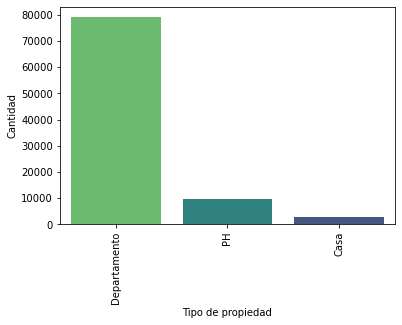

In [9]:
sns.countplot(x="property_type",data=d, palette="viridis_r")
plt.xticks(rotation=90)
plt.xlabel("Tipo de propiedad")
plt.ylabel("Cantidad")

In [10]:
tip=['Departamento','PH','Casa']
aaa=[]
for i in tip:
    a=d['property_type'].str.contains(i)
    aaa.append(a.sum())

for i in range(0,3):
    print(tipo[i],'=',aaa[i])

Departamento = 79029
PH = 9764
Casa = 2692


Este filtro deja ver que la mayoria de las casas se encuentran fuera de la capital federal y por esta razón el número disminuyó notablemente, PH pasa a ser la segunda propiedad con mayor cantidad después de los departamentos.

#### Filtrado de datos atipicos

Inicialmente se empezará realizando boxplots de superficie total, superficie cubierta y precios, respectivamente, para tener una visión global de cómo estan dispersos los datos

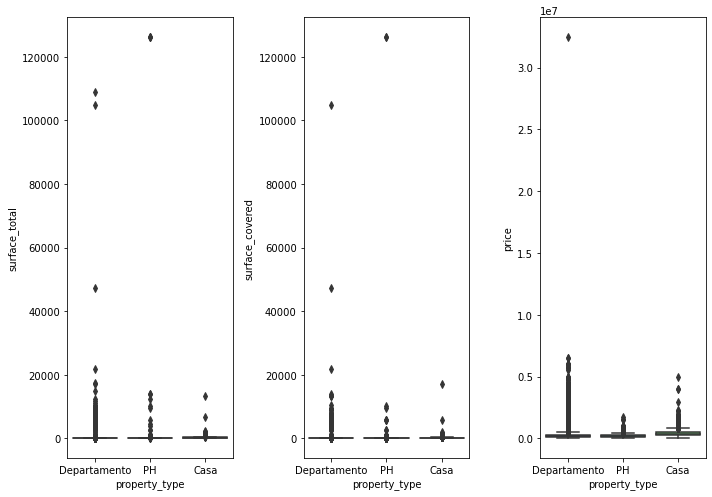

In [11]:
fig = plt.figure(figsize=(10, 20))
plt.subplot(331)
#Superficie total
sns.boxplot(data = d,x = 'property_type',y = "surface_total",palette="viridis")

plt.subplot(332)
#Superficie cubierta
sns.boxplot(data = d, x = 'property_type',y = "surface_covered",palette="viridis")

plt.subplot(333)
#Precio
sns.boxplot(data = d, x = 'property_type', y = "price",palette="viridis")

plt.tight_layout()

Como se puede ver que hay cierta cantidad de datos individuales que son muy grandes a comparacion del resto que se concentra en cierta region, por lo tanto lo ideal es realizar un filtro que ayude a visualizar mejor el comportamiento de los datos.

Para realizar el analisis del tipo de filtro que se usará en los datos, se procede a definir un par de funciones que se encargan de obtener los limites en los cuales esta la mayor parte de los datos del dataframe dejando por fuera los valores atipicos, esto usando el rango intercuartil. 

In [12]:
def limitst(df):
    Q1st = np.nanquantile(df.surface_total,0.25)
    Q3st = np.nanquantile(df.surface_total,0.75)
    IQRst = Q3st - Q1st
    LSst=Q3st+1.5*IQRst
    LIst= Q1st-1.5*IQRst
    return LSst, LIst

def limitp(df):
    Q1p = np.quantile(df.price,0.25)
    Q3p = np.quantile(df.price,0.75)
    IQRp = Q3p - Q1p
    LSp=Q3p+1.5*IQRp
    LIp= Q1p-1.5*IQRp
    return LSp, LIp

Ahora, para el primer filtro se tomara el dataset como un conjunto completo, de tal forma que se hallen los limiten globales de todas las instancias sin diferenciar.

### Filtro 1

In [13]:
print('el limite superior para superficie total del dataframe:',limitst(d)[0])
print('el limite superior para precio del dataframe:',limitp(d)[0])

el limite superior para superficie total del dataframe: 204.0
el limite superior para precio del dataframe: 517500.0


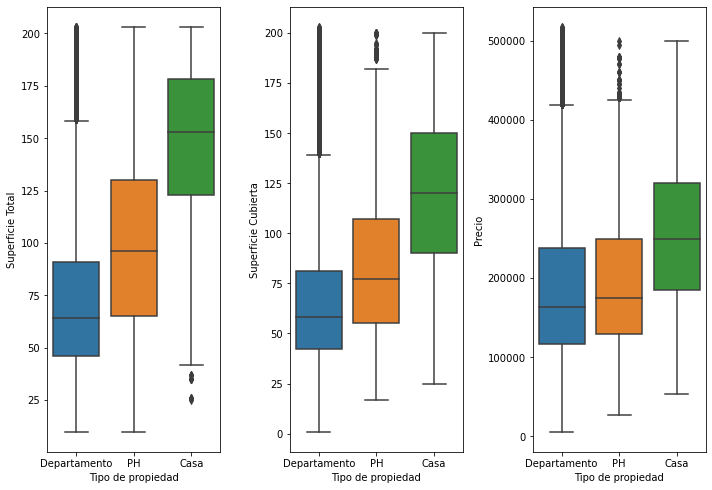

In [14]:
#filtro 1
fig = plt.figure(figsize=(10, 20))

plt.subplot(331)
#Filtro superficie total
filtro=d["surface_total"]<limitst(d)[0]
pf=d[filtro]
sns.boxplot(data = pf,x = 'property_type',y = "surface_total")
plt.ylabel("Superficie Total")
plt.xlabel("Tipo de propiedad")

plt.subplot(332)
#Filtro superficie cubierta
filtro2=pf["surface_total"]>=pf["surface_covered"]
sf=pf[filtro2]
sns.boxplot(data = sf, x = 'property_type',y = "surface_covered")
plt.ylabel("Superficie Cubierta")
plt.xlabel("Tipo de propiedad")

plt.subplot(333)
#Filtro precio
filtro3=sf["price"]<limitp(d)[0]
tf=sf[filtro3]
sns.boxplot(data = tf, x = 'property_type', y = "price")
plt.ylabel("Precio")
plt.xlabel('Tipo de propiedad')

plt.tight_layout()

Al ver los resultados del boxplot, es posible darse cuenta que al hacer el calculo del limite, este da resultados globales de todos los datos en conjunto, por lo tanto lo ideal seria hacerlo por tipo de propiedad, de esta forma se garantiza que al menos la mayoria de los datos por categoria esten contenidos, esto dado que en la grafica anterior no se tiene certeza si al tomar cierto valor como limite globlal, este elimine muchas entradas de cierto tipo de propiedad en especifico. 

### Filtro 2

In [15]:
#Datos para tipo de propiedad: Departamento
departamento=d['property_type'].str.contains("Departament")
dep=d[departamento]

print('el limite superior para superficie total de Departamento:',limitst(dep)[0])
print('el limite superior para precio de Departamento:',limitp(dep)[0])

el limite superior para superficie total de Departamento: 177.0
el limite superior para precio de Departamento: 494000.0


In [16]:
#Datos para tipo de propiedad: PH
phh=d['property_type'].str.contains("PH")
ph=d[phh]

print('el limite superior para superficie total de PH:',limitst(ph)[0])
print('el limite superior para precio de PH:',limitp(ph)[0])

el limite superior para superficie total de PH: 275.0
el limite superior para precio de PH: 472500.0


In [17]:
#Datos para tipo de propiedad: Casa
casa=d['property_type'].str.contains("Casa")
cas=d[casa]

print('el limite superior para superficie total de PH:',limitst(cas)[0])
print('el limite superior para precio de PH:',limitp(cas)[0])

el limite superior para superficie total de PH: 579.0
el limite superior para precio de PH: 840000.0


Esto quiere decir que la conclusion anterior es cierta y si se toma los datos globales se pierde información al mirarlo por tipos de propiedad, por lo tanto es mejor considerar un filtro donde se tome que la superficie total sea de aproximadamente 579m$^2$. Para el caso del precio sucede lo mismo, se ve que el limite superior de departamento es de 494 mil dolares, para el PH tiene un limite similar al del departamento en 472.5 mil dolares, pero si se mira para las casas este se encuentra en 840 mil dolares, por lo tanto, lo ideal seria hacer el filtro alrededor de este valor.

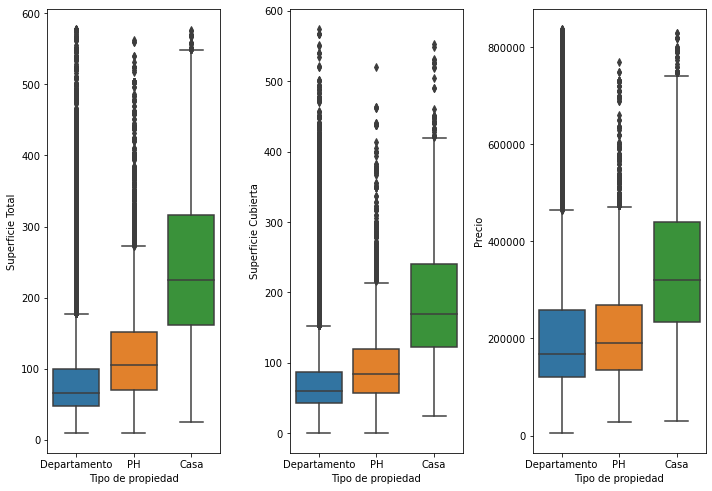

In [18]:
#filtro 2
fig = plt.figure(figsize=(10, 20))

plt.subplot(331)
#Filtro superficie total
filtro12=d["surface_total"]<limitst(cas)[0]
pf2=d[filtro12]
sns.boxplot(data = pf2,x = 'property_type',y = "surface_total")
plt.ylabel("Superficie Total")
plt.xlabel("Tipo de propiedad")

plt.subplot(332)
#Filtro superficie cubierta
filtro22=pf2["surface_total"]>=pf2["surface_covered"]
sf2=pf2[filtro22]
sns.boxplot(data = sf2, x = 'property_type',y = "surface_covered")
plt.ylabel("Superficie Cubierta")
plt.xlabel("Tipo de propiedad")

plt.subplot(333)
#Filtro precio
filtro32=sf2["price"]<limitp(cas)[0]
tf2=sf2[filtro32]
sns.boxplot(data = tf2, x = 'property_type', y = "price")
plt.ylabel("Precio")
plt.xlabel('Tipo de propiedad')

plt.tight_layout()

Text(0, 0.5, 'Cantidad')

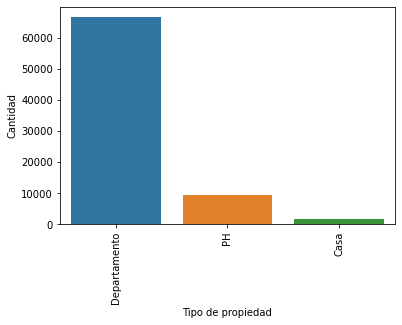

In [19]:
sns.countplot(x="property_type",data=tf2)
plt.xticks(rotation=90)
plt.xlabel("Tipo de propiedad")
plt.ylabel("Cantidad")

In [20]:
aa2=[]
for i in tipo:
    a=tf2['property_type'].str.contains(i)
    aa2.append(a.sum())

for i in range(0,3):
    print(tipo[i],'=',aa2[i])

Departamento = 66584
PH = 9557
Casa = 1886


Debido a que al tomar el limite de los datos de Casa como filtro global del dataframe, se obtiene un porcentaje mayor de datos de Departamento y PH debido a que estos tiene un limite mucho menor, se considero la idea de hacer un filtro por cada tipo de propiedad

### Filtro 3

In [21]:
#filtro 3
filtrodep=d['property_type'].str.contains("Departament")
fdep=d[filtrodep]
f1=np.logical_and(fdep['surface_total']<limitst(dep)[0],fdep['price']<limitp(dep)[0])
ff1=fdep[f1]

filtroph=d['property_type'].str.contains("PH")
fph=d[filtroph]
f2=np.logical_and(fph['surface_total']<limitst(ph)[0],fph['price']<limitp(ph)[0])
ff2=fph[f2]

filtrocasa=tf2['property_type'].str.contains("Casa")
ff3=tf2[filtrocasa]


nw=ff1.append(ff2)
nw=nw.append(ff3)

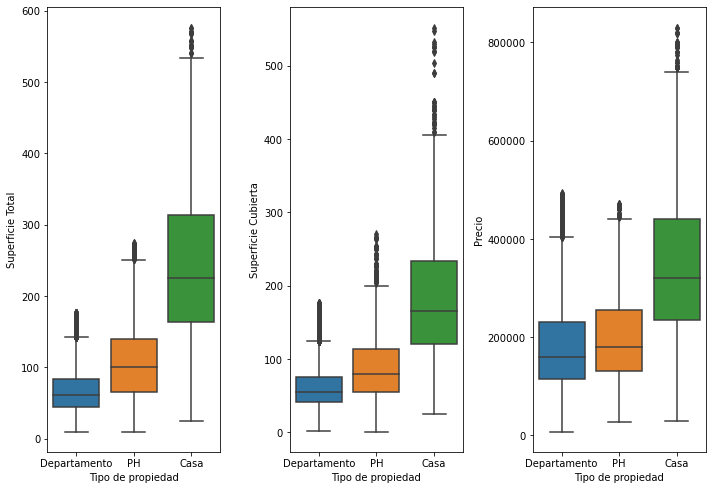

In [22]:
fig = plt.figure(figsize=(10, 20))

plt.subplot(331)
#superficie total
sns.boxplot(data = nw,x = 'property_type',y = "surface_total")
plt.ylabel("Superficie Total")
plt.xlabel("Tipo de propiedad")

plt.subplot(332)
#superficie cubierta
filtro23=nw["surface_total"]>=nw["surface_covered"]
sf3=nw[filtro23]
sns.boxplot(data = sf3, x = 'property_type',y = "surface_covered")
plt.ylabel("Superficie Cubierta")
plt.xlabel("Tipo de propiedad")

plt.subplot(333)
#precio
nw1=sf3
sns.boxplot(data = nw1, x = 'property_type', y = "price")
plt.ylabel("Precio")
plt.xlabel('Tipo de propiedad')

plt.tight_layout()

Text(0, 0.5, 'Cantidad')

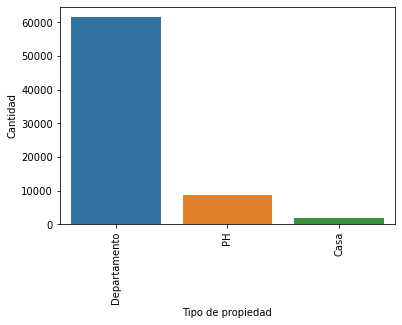

In [23]:
sns.countplot(x="property_type",data=nw1)
plt.xticks(rotation=90)
plt.xlabel("Tipo de propiedad")
plt.ylabel("Cantidad")

In [24]:
aa3=[]
for i in tipo:
    a=nw1['property_type'].str.contains(i)
    aa3.append(a.sum())

for i in range(0,3):
    print(tipo[i],'=',aa3[i])

Departamento = 61522
PH = 8761
Casa = 1886


Para decidir entre el segundo y tercer filtro, graficaremos los datos de superficie total respecto al precio para ver cómo los filtros influyen en la visualización de los datos.

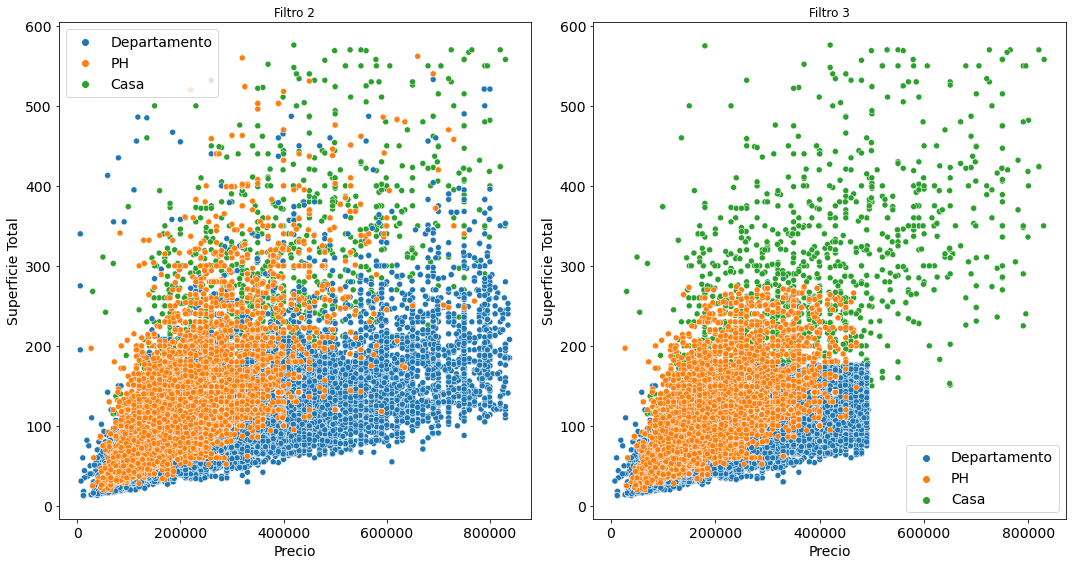

In [25]:
fig = plt.figure(figsize=(15, 15))
tfv = tf2.sort_values(by=['property_type'], ascending=True)
tfv2= nw1.sort_values(by=['property_type'], ascending=True)

plt.subplot(221)
sns.scatterplot(data=tfv,x="price", y="surface_total", hue = 'property_type',hue_order=['Departamento','PH','Casa'])
plt.tick_params(labelsize=14)
plt.ylabel("Superficie Total",fontsize=14)
plt.xlabel("Precio",fontsize=14)
plt.legend(fontsize='14')
plt.title('Filtro 2')

plt.subplot(222)
sns.scatterplot(data=tfv2,x="price", y="surface_total", hue = 'property_type',hue_order=['Departamento','PH','Casa'])
plt.tick_params(labelsize=14)
plt.ylabel("Superficie Total",fontsize=14)
plt.xlabel("Precio",fontsize=14)
plt.legend(fontsize='14')
plt.title('Filtro 3')

plt.tight_layout()

En la segunda grafica, correspondiente al tercer filtro, se puede ver que en este no se tendria en sí una vista global bajo cierto limite especifico sino que se encontrarian limites por datos dependiendo de la propiedad, segun esto para que al visualizar el analisis este tenga un sentido más completo, se toman los datos del segundo filtro. Se puede apreciar más claramente que la cantidad de Casas es mucho menor en comparación con los departamentos y los PH, tal como se muestra en los anteriores histogramas.

Volviendo al boxplot del filtro 2, se tiene información que no hemos analizado, se volverá a graficar para que sea más claro

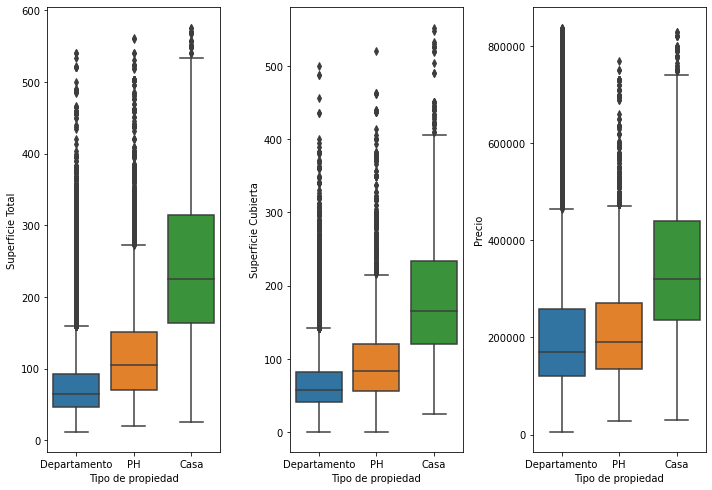

In [26]:
#filtro 2
fig = plt.figure(figsize=(10, 20))

plt.subplot(331)
#superficie total
sns.boxplot(data = tf2,x = 'property_type',y = "surface_total")
plt.ylabel("Superficie Total")
plt.xlabel("Tipo de propiedad")

plt.subplot(332)
#superficie cubierta
sns.boxplot(data = tf2, x = 'property_type',y = "surface_covered")
plt.ylabel("Superficie Cubierta")
plt.xlabel("Tipo de propiedad")

plt.subplot(333)
#precio
sns.boxplot(data = tf2, x = 'property_type', y = "price")
plt.ylabel("Precio")
plt.xlabel('Tipo de propiedad')

plt.tight_layout()

Se ve que en general la superficie total y cubierta de los departamentos es la menor en comparación con PH y casa, siendo este ultimo tipo de propiedad la que tiene valores mayores en promedio de superficie, aun así, los valores de área de las casas se encuentra en un intervalo mayor a comparacion que PH y departamento, es decir que hay mayor variedad en cuanto al área de las casas que en cuanto a departamento o ph que tienen intervalos más pequeños. Ahora, si se mira el precio por tipo de propiedad, se ve que los departamentos y PH tienen valores en un intervalo similar, esto podria signficar que el metro cuadrado de los departamentos suele ser más costoso o de igual valor que el de los PH, sin embargo parece que las casas son las que tienden a tener un mayor valor y un intervalo más amplio de precios.

##### Relación entre variables

Teniendo en cuenta que para el pairplot no es necesario cierta información contenida en el data frame, se filtrara para este.

In [27]:
tf2.head()

,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type
0,2019-10-17,2019-12-23,2019-10-17,-34.605880,-58.384949,Argentina,Capital Federal,San Cristobal,7.0,7.0,2.0,140.0,140.0,153000.0,USD,"***Venta semipiso centro, ideal hostel*****",DESCRIPCION DE LA PROPIEDAD: Departamento de 1...,Departamento,Venta
1,2019-10-17,2019-11-21,2019-10-17,-34.624056,-58.412110,Argentina,Capital Federal,Boedo,2.0,1.0,2.0,70.0,58.0,159000.0,USD,Espectacular PH reciclado en Boedo sin expensas.,PH reciclado en Boedo a una cuadra de la plaz...,PH,Venta
2,2019-10-17,2019-11-01,2019-10-17,-34.593569,-58.427474,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,45.0,45.0,125000.0,USD,Depto.tipo casa de 2 ambientes en Venta en Pal...,"2 ambienets amplio , excelente estado , patio ...",PH,Venta
3,2019-10-17,2019-12-23,2019-10-17,-34.581294,-58.436754,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,85.0,50.0,295000.0,USD,COSTA RICA 5800 / PALERMO HOLLYWOOD / VENTA PH...,HERMOSO PH EN PALERMO!!!2 AMBIENTES TOTALMENTE...,PH,Venta
5,2019-10-17,2019-11-01,2019-10-17,-34.593779,-58.441239,Argentina,Capital Federal,Villa Crespo,2.0,1.0,1.0,56.0,56.0,150000.0,USD,Depto.tipo casa de 2 ambientes en Venta en Vil...,"Excelente ph solo 2 unidades, no paga expensas...",PH,Venta


Se omite información como fecha de publicación y venta puesto que no tiene mucho sentido buscar relaciones con el resto de variables desde un punto de vista de un pairplot al igual que longitud y latitud, el resto se omiten por ser variables categoricas o que no dan información que se graficable tales como descripcion y titulo.

In [28]:
fc=tf2.drop(columns=['start_date','end_date','created_on','lat','lon','l1','l2','l3','currency','title','description','operation_type'],inplace=False)
fc.head()

,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
0,7.0,7.0,2.0,140.0,140.0,153000.0,Departamento
1,2.0,1.0,2.0,70.0,58.0,159000.0,PH
2,2.0,1.0,1.0,45.0,45.0,125000.0,PH
3,2.0,1.0,1.0,85.0,50.0,295000.0,PH
5,2.0,1.0,1.0,56.0,56.0,150000.0,PH


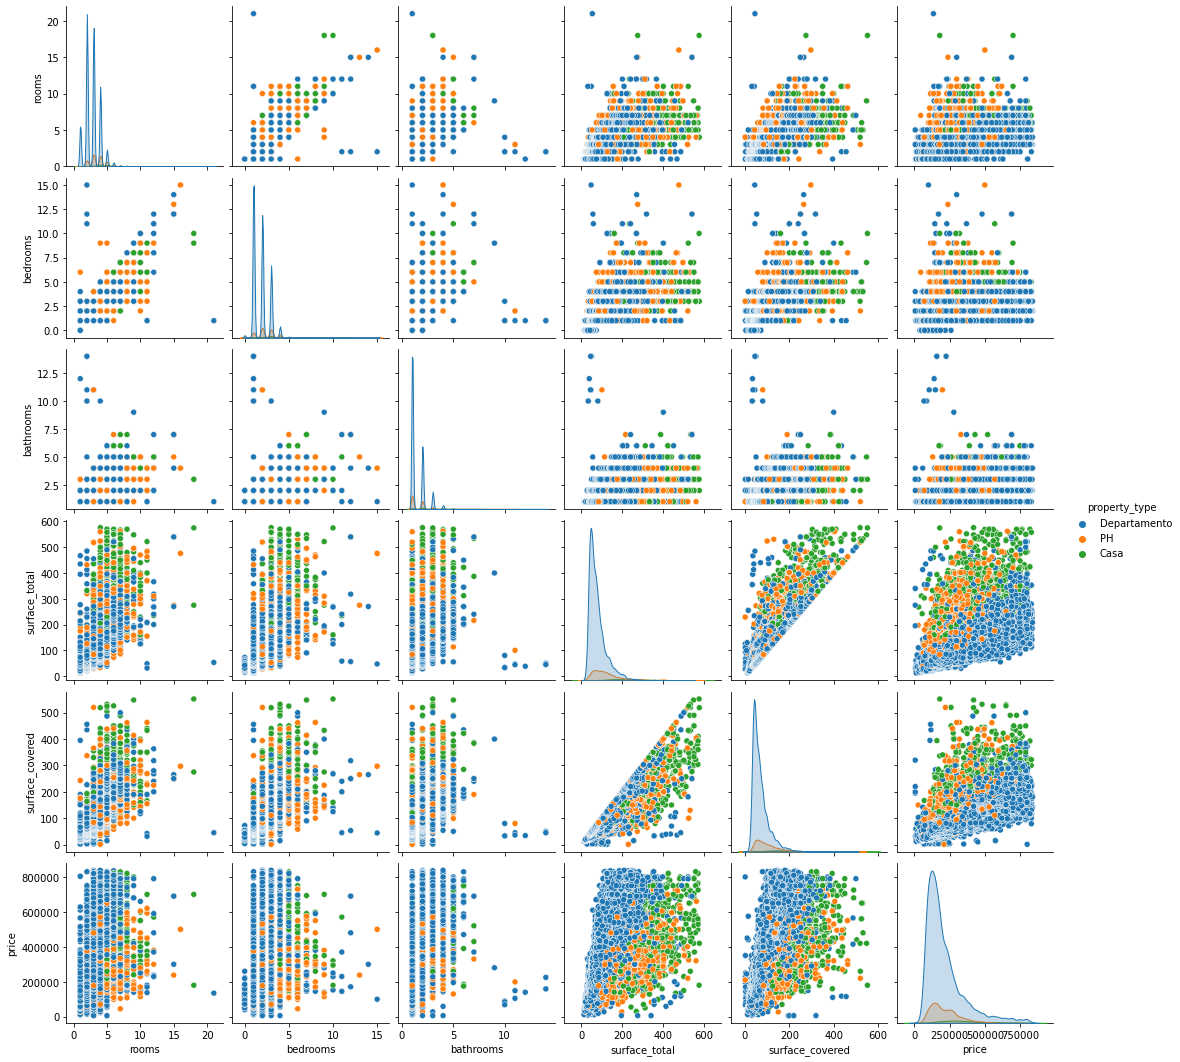

In [29]:
sns.pairplot(fc, hue = 'property_type',dropna=True)

De este pairplot se obtiene información interesante, tal como los histogramas de cada variable, esto nos da una idea de las caracteristicas de los tipos de propiedad.

##### Caracteristicas de las propiedades

In [30]:
depar=tf2['property_type'].str.contains("Departamento")
fdep2=tf2[depar]

prh=tf2['property_type'].str.contains("PH")
fph2=tf2[prh]

hou=tf2['property_type'].str.contains("Casa")
fcas2=tf2[hou]

In [31]:
def limitrooms(df):
    Q1p = np.quantile(df.rooms,0.25)
    Q3p = np.quantile(df.rooms,0.75)
    IQRp = Q3p - Q1p
    LSp=Q3p+1.5*IQRp
    LIp= Q1p-1.5*IQRp
    return LSp, LIp

def limitbedrooms(df):
    Q1p = np.quantile(df.bedrooms,0.25)
    Q3p = np.quantile(df.bedrooms,0.75)
    IQRp = Q3p - Q1p
    LSp=Q3p+1.5*IQRp
    LIp= Q1p-1.5*IQRp
    return LSp, LIp

def limitbathrooms(df):
    Q1p = np.nanquantile(df.bathrooms,0.25)
    Q3p = np.nanquantile(df.bathrooms,0.75)
    IQRp = Q3p - Q1p
    LSp=Q3p+1.5*IQRp
    LIp= Q1p-1.5*IQRp
    return LSp, LIp


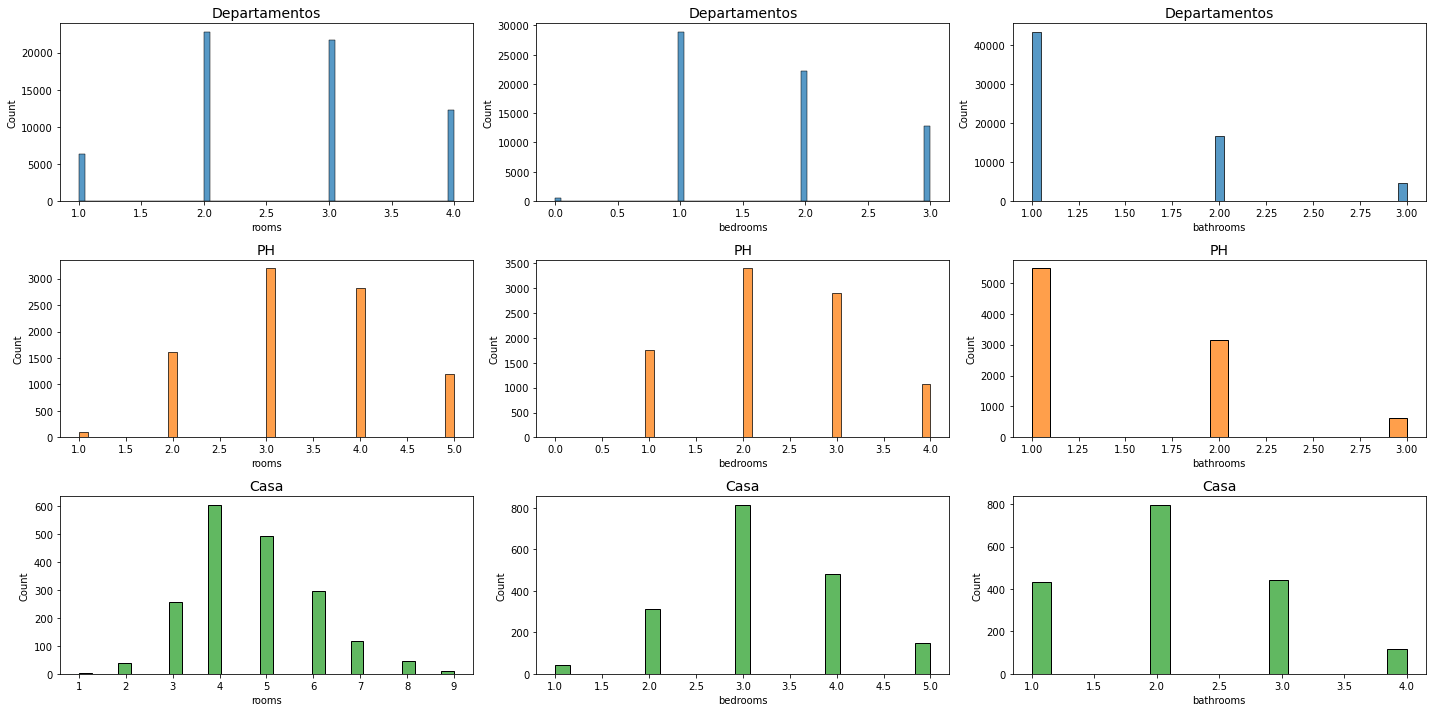

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(20,10))

axes[0,0].set_title('Departamentos',fontsize=14)
axes[0,1].set_title('Departamentos',fontsize=14)
axes[0,2].set_title('Departamentos',fontsize=14)

sns.histplot(ax=axes[0,0],data=fdep2[fdep2.rooms<=limitrooms(fdep2)[0]],x='rooms',color='#1f77b4')
sns.histplot(ax=axes[0,1],data=fdep2[fdep2.bedrooms<=limitbedrooms(fdep2)[0]],x='bedrooms',color='#1f77b4')
sns.histplot(ax=axes[0,2],data=fdep2[fdep2.bathrooms<=limitbathrooms(fdep2)[0]],x='bathrooms',color='#1f77b4')

axes[1,0].set_title('PH',fontsize=14)
axes[1,1].set_title('PH',fontsize=14)
axes[1,2].set_title('PH',fontsize=14)
sns.histplot(ax=axes[1,0],data=fph2[fph2.rooms<=limitrooms(fph2)[0]],x='rooms',color='#ff7f0e')
sns.histplot(ax=axes[1,1],data=fph2[fph2.bedrooms<=limitbedrooms(fph2)[0]],x='bedrooms',color='#ff7f0e')
sns.histplot(ax=axes[1,2],data=fph2[fph2.bathrooms<=limitbathrooms(fph2)[0]],x='bathrooms',color='#ff7f0e')

axes[2,0].set_title('Casa',fontsize=14)
axes[2,1].set_title('Casa',fontsize=14)
axes[2,2].set_title('Casa',fontsize=14)
sns.histplot(ax=axes[2,0],data=fcas2[fcas2.rooms<=limitrooms(fcas2)[0]],x='rooms',color='#2ca02c')
sns.histplot(ax=axes[2,1],data=fcas2[fcas2.bedrooms<=limitbedrooms(fcas2)[0]],x='bedrooms',color='#2ca02c')
sns.histplot(ax=axes[2,2],data=fcas2[fcas2.bathrooms<=limitbathrooms(fcas2)[0]],x='bathrooms',color='#2ca02c')

fig.tight_layout()

De estos histogramas se puede ver que hay una tendencia a cierta cantidad particular de habitaciones, alcobas y baños dependiendo del tipo de propiedad. Los departamentos y los PH tienen un comportamiento similar, sin embargo en cuanto a cantidad los PH suelen tener sus picos en una unidad más, es decir, mientras la mayoria de los departamentos tienen entre 2 y 3 habitaciones, los PH tienen entre 3 y 4, similarmente sucede entre PH y casa, teniendo la mayoria de estas ultimas entre 4 y 5 habitaciones. Se repite en cuanto al numero de alcobas, la mayoria de los departamentos tiene entre 1 y 2 alcobas, mientras los PH entre 2 y 3, y las casas entre 3 y 4 alcobas. En cuanto al número de baños los departamentos y los PH en su mayoria tienen entre 1 y 2 baños mientras que las casas tienen entre 2 y 3. Todo lo anterior se hizo analizando el número de propiedades que tienen estos atributos en especifico y seleccionando los dos que cuentan con mayor cantidad de instancias. Esto tiene sentido puesto que se espera que haya cierta correlacion entre la superficie de las propiedades y el número de habitaciones y alcobas, esto ademas del analisis de la superficie de cada tipo de propiedad con el boxplot que se hizo anteriormente.

#### Fechas de registro

Para analizar datos tales como fechas se puede realizar histogramas que dejen ver en dónde se concentran los datos. Se eliminaran fechas que no tengan sentido tales como fecha final en el año 9999, estas se interpretan como propiedades que aun no se han vendido.

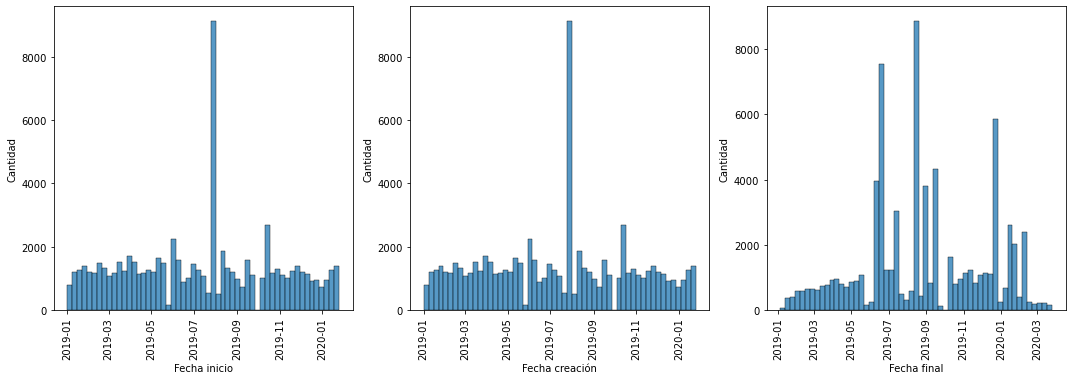

In [33]:
fec=tf2.copy()
fec2=fec['end_date'].str.contains('9999-12-31')
fec=fec[~fec2]

fec.start_date=pd.to_datetime(fec['start_date'])
fec.end_date=pd.to_datetime(fec['end_date'])
fec.created_on=pd.to_datetime(fec['created_on'])

fig = plt.figure(figsize=(15, 15))
plt.subplot(331)
sns.histplot(data = fec, x = 'start_date',bins=55)
plt.xticks(rotation = 90)
plt.ylabel("Cantidad")
plt.xlabel("Fecha inicio")

plt.subplot(332)
sns.histplot(data = fec, x = 'created_on',bins=55)
plt.xticks(rotation = 90)
plt.ylabel("Cantidad")
plt.xlabel("Fecha creación")

plt.subplot(333)
sns.histplot(data = fec, x = 'end_date',bins=55)
plt.xticks(rotation = 90)
plt.ylabel("Cantidad")
plt.xlabel("Fecha final")

plt.tight_layout()

In [34]:
#bin size
from datetime import datetime, timedelta
a=min(fec.start_date)-max(fec.start_date)
a=-a/timedelta(days=1)
a=a/55
print('Cada intervalo de los anteriores histogramas corresponde a:',a,'días')

Cada intervalo de los anteriores histogramas corresponde a: 7.072727272727272 días


No se adentrará mucho en cuanto al analisis de las fechas de publicacion y venta, en general vemos que la fecha de inicio concuerda con la fecha en la que se creo la entrada del inmueble a la base de datos. En intervalos de 7 días aprox, se encuentra cierto valor promedio de propiedades que se ponen a la venta, sin embargo hay un par de semanas en las cuales no se registran propiedades para la venta o muy pocas, tales como la semana entre finales de mayo e inicios de junio del 2019 y finales de septiembre e inicio de octubre del 2019, sin embargo, hay un pico de propiedades que se ingresan a la venta entre finales del mes de julio y e inicios de septiembre. En cuanto a la fecha de culminación, la cual se interpreta como la fecha de venta, no se ve un patron en especifico, pareciera que en los primeros meses del 2019 empieza a crecer el número de ventas de propiedades gradualmente hasta que se empiezan a encontrar ciertos picos de ventas para ciertas semanas luego de aproximadamente el mes de junio del 2019. Si se compara la venta de propiedades de los inicios del 2019 respecto a los inicios del 2020, se ve que en el 2020 se vendio mayor cantidad de propiedades.

##### Correlación entre las variables

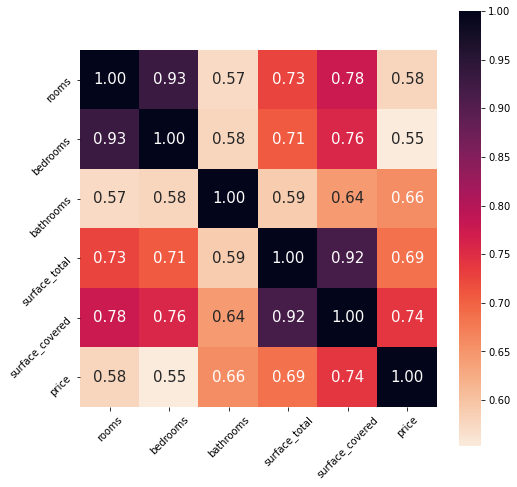

In [35]:
corr = fc.drop(columns = 'property_type').corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr, cbar = True,  square = True, annot=True, fmt= '.2f',annot_kws={'size': 15},
           xticklabels= fc.drop(columns = 'property_type').columns, 
           yticklabels= fc.drop(columns = 'property_type').columns,
           cmap= "rocket_r")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

En la primera vista del mapa de calor que nos muestra las correlaciones, se puede ver que la variable que tiene mayor relacion respecto al precio de la propiedad es la superficie cubierta, esto quiere decir que esta es la variable que más influye en el precio de una propiedad junto a la superficie total. Esto implica que entre mayor sea el número, la correlación es mayor y esta variable influye más en el precio. Sin embargo, más allá del precio, tambien hay ciertas variables que se correlacionan muy bien tales como superficie total y cubierta lo cual tiene claramente sentido, además de la correlacion entre número de habitaciones y de alcobas. 

Ahora, con el fin de visualizar la correlacion entre precio y superficie, se procede a graficar superficie total y cubierta respecto a precio.

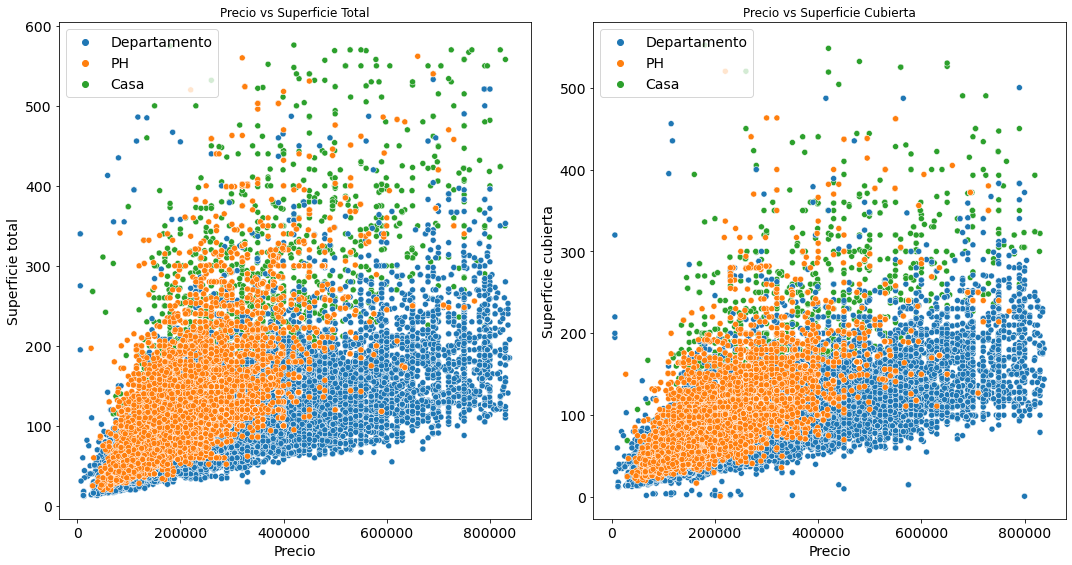

In [36]:
fig = plt.figure(figsize=(15, 15))
tfv = tf2.sort_values(by=['property_type'], ascending=True)
tfv2= nw1.sort_values(by=['property_type'], ascending=True)

plt.subplot(221)
sns.scatterplot(data=tfv,x="price", y="surface_total", hue = 'property_type',hue_order=['Departamento','PH','Casa'])
plt.tick_params(labelsize=14)
plt.ylabel("Superficie total",fontsize=14)
plt.xlabel("Precio",fontsize=14)
plt.legend(fontsize='14')
plt.title('Precio vs Superficie Total')

plt.subplot(222)
sns.scatterplot(data=tfv,x="price", y="surface_covered", hue = 'property_type',hue_order=['Departamento','PH','Casa'])
plt.tick_params(labelsize=14)
plt.ylabel("Superficie cubierta",fontsize=14)
plt.xlabel("Precio",fontsize=14)
plt.legend(fontsize='14')
plt.title('Precio vs Superficie Cubierta')

plt.tight_layout()

La primera anotación en cuanto a las dos graficas es que en cuanto a la superficie total se nota una mayor dispersion de datos que a comparación de la superficie cubierta, esto tiene sentido ya que lo normal es que el area total sea mayor o igual que la superficie cubierta, sin embargo esto tambien implica que en cuanto a la superficie total suelen haber más propiedades que tienen el mismo precio pero diferente área total, esta prodria ser una de las razones por las cuales la superficie cubierta tiene mayor correlacion en cuanto al precio. Hay, ademas, ciertos factores a tener en cuenta en ambas graficas, por ejemplo que lo comun es que el precio aumente a medida que el área es mayor. 

Si revisamos los datos por tipo de propiedad se observa que para los departamentos hay un espectro más grande de propiedades con un precio mayor para cierta área, es decir que hay departamentos con cierta área en especifico a los cuales el precio varia en un intervalo más grande que por ejemplo con los PH. En cuanto a las casas se logra notar que su cantidad es mucho menor en comparacion con PH y departamento, sin embargo son las que suelen tener áreas más grandes y un espectro de precios amplio. Es importante tener en cuenta que la informacion que se lee en las graficas varia de acuerdo al valor del metro cuadrado por barrio, esta es la explicacion a que para ciertas propiedades con un área en especifico exista un intervalo tan grande de precios diferentes.

#### Precio por metro cuadrado por barrio

A continuacion se hallará el precio promedio del metro cuadrado por barrio.

In [37]:
barrios=tf2['l3'].unique()
bd=[]
for i in barrios:
    a=fdep2['l3'].str.fullmatch(i)
    bd.append(a.sum())

bph=[]
for i in barrios:
    a=fph2['l3'].str.fullmatch(i)
    bph.append(a.sum())

bcas=[]
for i in barrios:
    a=fcas2['l3'].str.fullmatch(i)
    bcas.append(a.sum())
    
pm2= tf2.price/tf2.surface_total
ctf2=tf2.copy()

ctf2['price_m2']=pm2
b=0
pmm2=[]
for i in barrios:
    a=ctf2['l3'].str.fullmatch(i)
    nvv=ctf2[a]
    pmm2.append(nvv['price_m2'].sum()/len(nvv))

dtfb={'Barrios':barrios,'Departamentos': bd, 'PH': bph, 'Casa':bcas, 'Precio_m2': pmm2}
dtfb=pd.DataFrame(dtfb)
dtfb=dtfb.sort_values(by=['Precio_m2'], ascending = False)

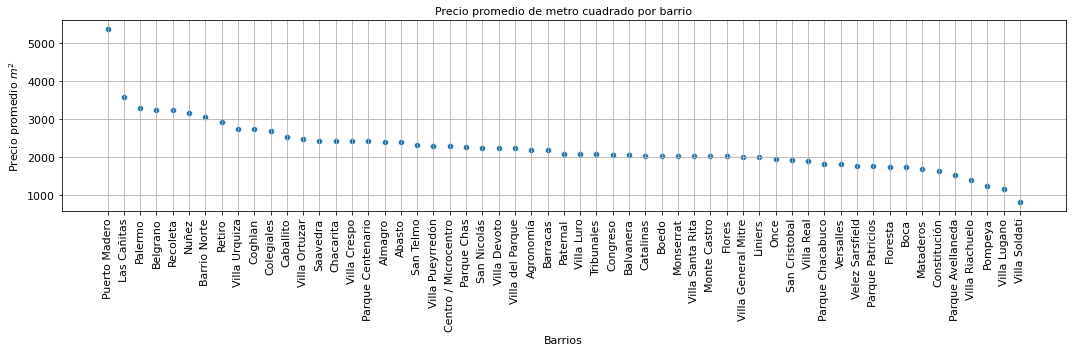

In [38]:
plt.figure(figsize=(15, 5))
plt.subplot(111)
sns.scatterplot(data=dtfb,y='Precio_m2',x='Barrios')
plt.ylabel("Precio promedio $m^{2}$",fontsize=11)
plt.xlabel("Barrios",fontsize=11)
plt.xticks(rotation=90)
plt.title('Precio promedio de metro cuadrado por barrio',fontsize=11)
plt.tick_params(labelsize=11)
plt.grid()

plt.tight_layout()

De la información obtenida en la grafica anterior, vemos que el metro cuadrado de mayor valor es el del barrio Puerto Madero y el de menor es Villa Soldati.

#### ¿Qué propiedades se venden en menor tiempo?

Conocemos la fecha en la que se publica la propiedad y la fecha en la que se retira esta de la base de datos, reconociendo la diferencia entre las fechas es posible conocer cuanto tiempo tardó en ser vendida la propiedad.

In [39]:
dates = tf2[['start_date','end_date']].copy()
fdt=dates['end_date'].str.contains('9999-12-31')
fdt2=dates[~fdt]

dates=fdt2.copy()
tf22=tf2.copy()

dates.start_date=pd.to_datetime(dates['start_date'])
dates.end_date=pd.to_datetime(dates['end_date'])
time=dates.end_date-dates.start_date

time=time/timedelta(days=1)

tf22["time"]=time


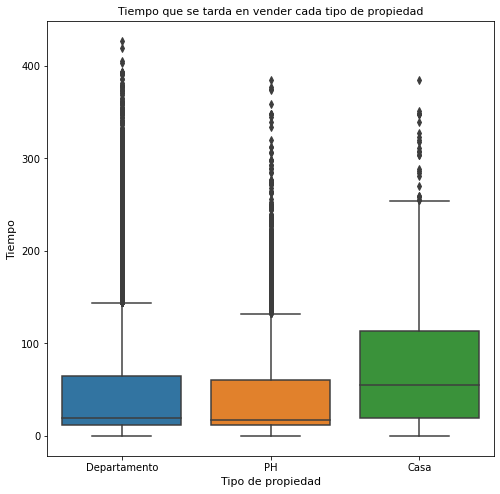

In [40]:
plt.figure(figsize=(8, 8))
sns.boxplot(data = tf22,y = 'time',x = "property_type")
plt.xlabel("Tipo de propiedad",fontsize=11)
plt.ylabel("Tiempo",fontsize=11)
plt.title('Tiempo que se tarda en vender cada tipo de propiedad',fontsize=11)
plt.show()

Del boxplot obtenido se interpreta que las propiedades que suelen "tardar más" en vender son las casas, sus datos se concentran en un intervalo más grande de tiempo comparado con los departamentos y los PH, de estos dos ultimos se infiere que se comportan de forma muy similar en cuanto a tiempo de venta.

##### Correlación tiempo de venta

Esta información por sí sola no nos dice mucho. Miremos cual es la correlación entre el tiempo de venta con las demás variables.

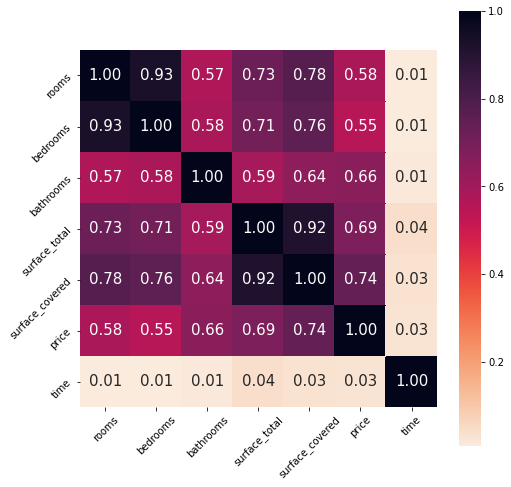

In [41]:
tf22=tf22.drop(columns=['start_date','end_date','created_on','lat','lon','l1','l2','l3','currency','title','description','operation_type'],inplace=False)
corr = tf22.drop(columns = 'property_type').corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr, cbar = True,  square = True, annot=True, fmt= '.2f',annot_kws={'size': 15},
           xticklabels= tf22.drop(columns = 'property_type').columns, 
           yticklabels= tf22.drop(columns = 'property_type').columns,
           cmap= "rocket_r")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

Lo anterior quiere decir que no hay ninguna variable con la cual contemos que permita determinar el tiempo que se tarda en vender una propiedad. Factores como la oferta y demanda por barrio quizá tengan cierta correlación con el tiempo de venta, sin embargo, esto depende de muchos otros factores como la dinamica economica del pais o ciudad en ciertas fechas, y la ubicación del inmueble en cuanto a una dinamica social, por ejemplo, si hay parques cerca o universidades.

### Dataset inmuebles Colombia

Antes de hacer una pregunta que se pueda resolver con la base de datos argentina y una nueva base de datos colombiana, procedemos a filtrar un poco la base de datos de Colombia.

Inicialmente se eliminan las columnas que no se crean necesarias para la pregunta que se desea hacer, ademas se omiten los valores faltandes de la base de datos y se toman solo las propiedades que esten en venta.

In [124]:
cold=pd.read_csv('co_properties.csv')
cold=cold.drop(columns=['id','ad_type','created_on','lat','lon','l4','l5','l6','title','description','price_period'],inplace=False)
cold=cold[cold['operation_type'].str.fullmatch('Venta')]

coldt=cold.dropna()
coldt.head()

,start_date,end_date,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,property_type,operation_type
428,2020-12-08,2021-02-02,Colombia,Cundinamarca,Bogotá D.C,1.0,1.0,2.0,86.0,86.0,4.700000e+08,COP,Oficina,Venta
429,2020-12-08,2021-03-16,Colombia,Cundinamarca,Bogotá D.C,1.0,1.0,5.0,389.0,389.0,2.400000e+09,COP,Oficina,Venta
452,2020-12-08,2021-01-19,Colombia,Cundinamarca,Bogotá D.C,1.0,1.0,1.0,47.0,47.0,3.450000e+08,COP,Apartamento,Venta
460,2020-12-08,2021-03-16,Colombia,Magdalena,Santa Marta,1.0,1.0,1.0,37.0,37.0,2.400000e+08,COP,Apartamento,Venta
461,2020-12-08,2021-03-08,Colombia,Atlántico,Barranquilla,1.0,1.0,1.0,43.0,43.0,1.700000e+08,COP,Apartamento,Venta


Text(0, 0.5, 'Cantidad')

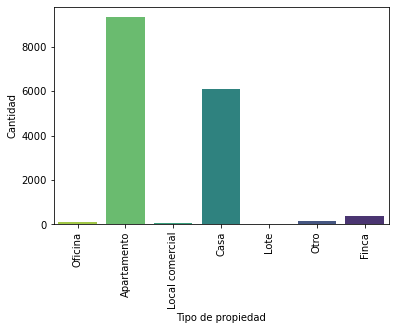

In [78]:
sns.countplot(x="property_type",data=coldt, palette="viridis_r")
plt.xticks(rotation=90)
plt.xlabel("Tipo de propiedad")
plt.ylabel("Cantidad")

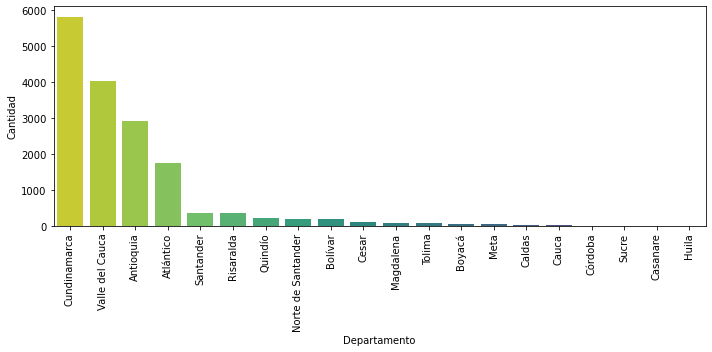

In [79]:
fig = plt.figure(figsize=(10, 5))

sns.countplot(x="l2",data=coldt, palette="viridis_r",order = coldt['l2'].value_counts().index)
plt.xticks(rotation=90)
plt.xlabel("Departamento")
plt.ylabel("Cantidad")

plt.tight_layout()

Con la información anterior que nos muestra qué tipo de propiedades hay en la base de datos y la cantidad de inmuebles por departamento, se procede a filtrar la base de datos por Casas y Apartamentos en cuanto a tipo de propiedad y en cuanto a region se filtra para los tres departamentos con mayor numero de instancias los cuales son Cundinamarca, Valle del Cauca, Antioquia y Atlántico.

In [101]:
col1=np.logical_or(coldt['property_type'].str.fullmatch("Casa"),coldt['property_type'].str.fullmatch("Apartamento"))

orr=np.logical_or(coldt['l2'].str.fullmatch("Cundinamarca"),coldt['l2'].str.fullmatch("Valle del Cauca"))
orr2=np.logical_or(coldt['l2'].str.fullmatch('Antlántico'),coldt['l2'].str.fullmatch('Antioquia'))

col2=np.logical_and(col1,np.logical_or(orr,orr2))
col=coldt[col2]
col.head()

,start_date,end_date,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,property_type,operation_type
452,2020-12-08,2021-01-19,Colombia,Cundinamarca,Bogotá D.C,1.0,1.0,1.0,47.0,47.0,345000000.0,COP,Apartamento,Venta
470,2020-12-08,2021-01-12,Colombia,Cundinamarca,La Calera,2.0,2.0,2.0,1220.0,145.0,580000000.0,COP,Casa,Venta
484,2020-12-08,2021-02-08,Colombia,Antioquia,Envigado,2.0,2.0,2.0,62.0,62.0,295000000.0,COP,Apartamento,Venta
485,2020-12-08,2021-01-14,Colombia,Antioquia,Envigado,2.0,2.0,2.0,79.0,79.0,430000000.0,COP,Apartamento,Venta
511,2020-12-08,2021-01-19,Colombia,Cundinamarca,Bogotá D.C,2.0,2.0,2.0,84.0,84.0,600000000.0,COP,Apartamento,Venta


Ahora se eliminan outliers

In [114]:
apacol=col['property_type'].str.contains("Apartamento")
apcol=col[apacol]
print('el limite superior para superficie total de apartamento:',limitst(apcol)[0])
print('el limite superior para precio de apartamento:',limitp(apcol)[0])

print('-----------------')

casacol=col['property_type'].str.contains("Casa")
cascol=col[casacol]
print('el limite superior para superficie total de casa:',limitst(cascol)[0])
print('el limite superior para precio de casa:',limitp(cascol)[0])

el limite superior para superficie total de apartamento: 229.0
el limite superior para precio de apartamento: 1257500000.0
-----------------
el limite superior para superficie total de casa: 1478.5
el limite superior para precio de casa: 2930000000.0


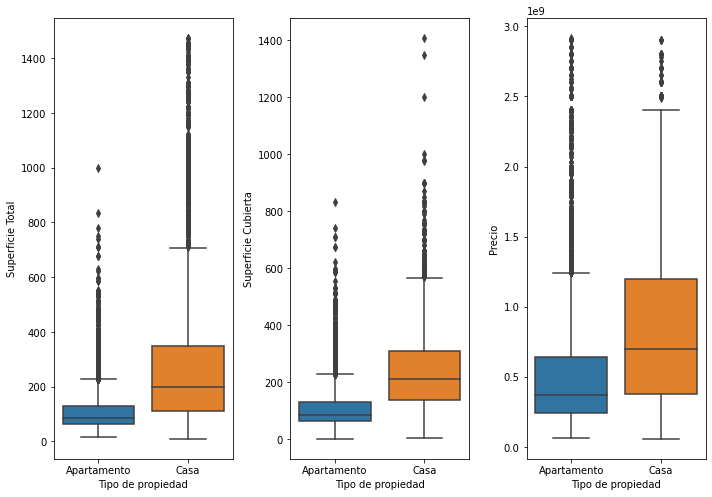

In [115]:
#filtro 2

fig = plt.figure(figsize=(10, 20))

plt.subplot(331)
#Filtro superficie total
filtrocol12=col["surface_total"]<limitst(cascol)[0]
pfcol2=col[filtrocol12]
sns.boxplot(data = pfcol2,x = 'property_type',y = "surface_total")
plt.ylabel("Superficie Total")
plt.xlabel("Tipo de propiedad")

plt.subplot(332)
#Filtro superficie cubierta
filtrocol22=pfcol2["surface_total"]>=pfcol2["surface_covered"]
sfcol2=pfcol2[filtrocol22]
sns.boxplot(data = sfcol2, x = 'property_type',y = "surface_covered")
plt.ylabel("Superficie Cubierta")
plt.xlabel("Tipo de propiedad")

plt.subplot(333)
#Filtro precio
filtrocol32=sfcol2["price"]<limitp(cascol)[0]
tfcol2=sfcol2[filtrocol32]
sns.boxplot(data = tfcol2, x = 'property_type', y = "price")
plt.ylabel("Precio")
plt.xlabel('Tipo de propiedad')

plt.tight_layout()

Del anterior boxplot se pueden obtener varias anotaciones tales como el hecho de que los apartamentos tienen superficie total y cubierta menor que las casas, ademas el intervalo en el que se encuentra la mayoria de los datos es mucho más pequeño en comparacion con las casas, esto quiere decir que no hay gran variedad de áreas para los apartamentos, pero sí para las casas. Si se observan los precios, se nota que en general los apartamentos tienen mayor precio por metro cuadrado que algunas de las casas, esto debido a que hay cierta intercepcion de precios entre apartamento y casa aunque los apartamentos tengan una menor superficie que las casas en general. Esta dinamica es similar a la de la base de datos argentina.

Luego de filtrar los datos se procede a hacer la pregunta, inicialmente se considero comparar los precios de los inmuebles de ambos paises, sin embargo es necesario tener en cuenta que el precio del dolar varia en cada pais dependiendo de la fecha y las dinamicas economicas del pais en ese momento, por lo tanto es dificil realizar una conversion y ademas comparar valores de inmuebles de fechas diferentes. 

Veamos el tamaño de ambas bases de datos luego del filtrado.

In [128]:
print('Tamaño base de datos colombiana luego del filtro:',tfcol2.shape)
print('Tamaño base de datos argentina luego del filtro:',tf2.shape)

Tamaño base de datos colombiana luego del filtro: (9494, 14)
Tamaño base de datos argentina luego del filtro: (78027, 19)


Otro factor a tener en cuenta, es que luego del filtrado de la base de datos colombiana, esta quedo con muy pocas instancias en comparación con los de la base de datos de Argentina. No es posible generar conclusiones de esta diferencia de tamaño puesto que hay muchos factores a tener en cuenta que quizá se pasan por alto, aun así vemos que hay gran cantidad de datos faltantes en la base de datos colombiana en comparacion con la base de datos argentina los cuales fueron descartados inicialmente al hacer el filtro.

In [125]:
vfaltantecol=cold.isna()
print('valores faltantes base de datos colombiana:')
vfaltantecol.sum()

valores faltantes base de datos colombiana:


start_date              0
end_date                0
l1                      0
l2                      0
l3                  37324
rooms              473716
bedrooms           434003
bathrooms          132593
surface_total      549739
surface_covered    535380
price                 492
currency              509
property_type           0
operation_type          0
dtype: int64

In [126]:
print('valores faltantes base de datos argentina:')
vfaltante.sum()

valores faltantes base de datos argentina:


start_date             0
end_date               0
created_on             0
lat                 9925
lon                 9959
l1                     0
l2                     0
l3                     0
rooms                  0
bedrooms               0
bathrooms           5957
surface_total      20527
surface_covered    21614
price                  0
currency               0
title                  0
description            0
property_type          0
operation_type         0
dtype: int64

Como la diferencia entre la cantidad de datos es muy grande, se considera absurdo intentar realizar una comparación entre las dos bases de datos, sin embargo, fue posible realizar un analisis muy general de la base de datos colombiana.

### 3. Machine Learning

En esta sección, debes entrenar dos modelos de Machine Learning - uno de vecinos más cercanos y otro de árboles de decisión -  para predecir el precio de las propiedades tipo `Departamento`, `PH` y `Casa`  en la Ciudad Autónoma de Buenos Aires (`Capital Federal`). 

In [43]:
#Filtro superficie total
filtroml=np.logical_and(d["surface_total"]<=1000,d["surface_total"]>=15)
pfml=d[filtroml]

#filtro precio
filtro2ml=pfml["price"]<=4e6
sfml=pfml[filtro2ml]

ml=sfml.drop(columns=['start_date','end_date','created_on','lat','lon','l1','l2','l3','currency','title','description','operation_type','property_type'],inplace=False)
mln=ml.dropna()
print('checkpoint:',mln.shape)

checkpoint: (81019, 6)


### Primer modelo

Inicialmente usaremos como los atributos superficie total y cubierta para predecir el precio del inmueble.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error

X=mln[['surface_total', 'surface_covered']]
y=mln.price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(56713, 2) (56713,) (24306, 2) (24306,)


Antes de buscar qué modelo predice mejor los datos, es necesario saber cuál es la forma más optima para los modelos de vecinos cercanos en cuanto al número de vecinos a tener en cuenta y para el modelo de arbol saber cual es la profundida optima, para eso se realizara un ciclo con diferentes valores de vecinos cercanos y profundidades las cuales se graficaran luego respecto al error medio cuadrado.

In [45]:
#Modelo de arbol

def tree_regressorrmse(X_train,y_train,X_test,y_test):
    lismse_train_ar=[]
    lismse_test_ar=[]
    lista= [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,50]
    
    for i in lista:
        tree_regressor = DecisionTreeRegressor(max_depth=i, random_state=42)
        tree_regressor.fit(X_train, y_train)

        y_train_pred_ar = tree_regressor.predict(X_train)
        y_test_pred_ar = tree_regressor.predict(X_test)

        rmse_train_ar = np.sqrt(mean_squared_error(y_train, y_train_pred_ar))
        rmse_test_ar =np.sqrt(mean_squared_error(y_test, y_test_pred_ar))
        
        lismse_train_ar.append(rmse_train_ar)
        lismse_test_ar.append(rmse_test_ar)
    return lismse_train_ar,lismse_test_ar

plt.plot(lista,tree_regressorrmse(X_train,y_train,X_test,y_test)[0],'o-',label='train' )
plt.plot(lista,tree_regressorrmse(X_train,y_train,X_test,y_test)[1],'o-',label='test')
plt.legend()
plt.xlabel('Profundidad arbol')
plt.ylabel('RMSE')

NameError: name 'lista' is not defined

Observando la grafica, vemos que apartir de la profundidad igual a 10 el error se estabiliza, siendo 10 el valor donde se ve menor diferencia entre train y test, se escoge este como el valor optimo de profundidad.

In [ ]:
def knnregressorrmse(X_train,y_train,X_test,y_test):
    lismse_train_knn=[]
    lismse_test_knn=[]
    lista= [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,50]
    for i in lista:
        knn_regressor = KNeighborsRegressor(n_neighbors=i)
        knn_regressor.fit(X_train, y_train)
        
        y_train_pred_knn = knn_regressor.predict(X_train)
        y_test_pred_knn = knn_regressor.predict(X_test)
        
        rmse_train_knn = np.sqrt(mean_squared_error(y_train, y_train_pred_knn))
        rmse_test_knn =np.sqrt(mean_squared_error(y_test, y_test_pred_knn))
        
        lismse_train_knn.append(rmse_train_knn)
        lismse_test_knn.append(rmse_test_knn)
        
    return lismse_train_knn,lismse_test_knn

plt.plot(lista,knnregressorrmse(X_train,y_train,X_test,y_test)[0],'o-',label='train' )
plt.plot(lista,knnregressorrmse(X_train,y_train,X_test,y_test)[1],'o-',label='test')
plt.legend()
plt.xlabel('Número de Vecinos')
plt.ylabel('RMSE')

Para este caso vemos que el punto minimo se encuentra en 4, por lo tanto se utilizara ese como el valor optimo de vecinos cercanos para el modelo.

In [ ]:
def gmodelos(X_train, y_train,X_test,y_test,maxdepth,nneighbors):
    linear_model = LinearRegression()
    tree_regressor = DecisionTreeRegressor(max_depth=maxdepth, random_state=42)
    knn_regressor = KNeighborsRegressor(n_neighbors=nneighbors)
    
    linear_model.fit(X_train, y_train)
    tree_regressor.fit(X_train, y_train)
    knn_regressor.fit(X_train, y_train)
    
    modelos = ['Regresión lineal', 'Árbol de Decisión', 'Vecinos más cercanos']
    for i, model in enumerate([linear_model, tree_regressor, knn_regressor]):
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        print(f'Modelo: {modelos[i]}')
        
        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
        print(f'Raíz del error cuadrático medio en Train: {rmse_train}')
        print(f'Raíz del error cuadrático medio en Test: {rmse_test}')
        
        plt.figure(figsize = (10,5))
        
        plt.subplot(1,2,1)
        sns.histplot(y_train - y_train_pred, bins = 150, label = 'train',kde=True, stat="density", linewidth=0,color="red")
        sns.histplot(y_test - y_test_pred, bins = 150, label = 'test', kde=True, stat="density", linewidth=0)
        plt.xlim(-0.3e6, 0.3e6)
        plt.xlabel('errores')
        plt.legend()
        
        ax = plt.subplot(1,2,2)
        ax.scatter(y_test,y_test_pred, s =2)
        
        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
            np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes]
        ]
        
        ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
        plt.xlabel('y (test)')
        plt.ylabel('y_pred (test)')

        plt.tight_layout()
        plt.show()
        
        
gmodelos(X_train, y_train,X_test,y_test,10,4)

De todos los modelos vemos algo en común y es que la mayoria de los errores grandes en la predicción de datos se dan para valores reales que se predicen con un precio menor al real. Estos suelen ser los errores más dispersos en la grafica.

Para el modelo de regresion lineal los errores de train y test son muy similares lo que indica que no hay gran sobreajuste, sin embargo estos son muy grandes, lo cual nos indica que  no es el mejor modelo para predecir los datos. En esta grafica de la regresion es la que más se observa errores en los cuales se tiende a clasificar un precio como mucho menor al precio real.

Para los modelos de regresion de arbol de decision y vecinos más cercanos, el error es menor y algo similar para ambos modelos, sin embargo el modelo de árbol de decision es el que cuenta con menor error para test, ademas la diferencia entre el error de test y train tambien es menor. Si observamos las graficas de precio real vs precio predicho, vemos que para el modelo de arbol de decision los datos tienden a estar más cerca de la linea de acierto que en el modelo de vecinos más cercanos, aunque realmente la diferencia es levemente apreciable. Por lo anterior se concluye que el mejor modelo para la predicion de los precios es el de árbol de decision.

### Segundo modelo

Ahora hagamos el mismo analisis pero tomando más atributos. En este caso tomaremos todos los del data set excepto price.

In [ ]:
X2=mln.drop("price", axis=1)
y=mln.price

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.30, random_state=42)
print(X2_train.shape, y2_train.shape, X2_test.shape, y2_test.shape)

In [ ]:
#Modelo árbol de decision 
plt.plot(lista,tree_regressorrmse(X2_train,y2_train,X2_test,y2_test)[0],'o-',label='train' )
plt.plot(lista,tree_regressorrmse(X2_train,y2_train,X2_test,y2_test)[1],'o-',label='test')
plt.legend()
plt.xlabel('Profundidad arbol')
plt.ylabel('RMSE')

De nuevo, vemos que la curva para test se estabiliza a partir de 10, aunque el valor de 15 sea solo un poco menor, la complejidad en cuanto a la diferencia del error para test y train es menor en 10 y por lo tanto se escoge este como valor optimo. 

In [ ]:
#Modelo vecinos más cercano
plt.plot(lista,knnregressorrmse(X2_train,y2_train,X2_test,y2_test)[0],'o-',label='train' )
plt.plot(lista,knnregressorrmse(X2_train,y2_train,X2_test,y2_test)[1],'o-',label='test')
plt.legend()
plt.xlabel('Número de Vecinos')
plt.ylabel('RMSE')

En este caso, vemos que el minimo de la curva para test se encuentra en 3, por lo tanto se escoge este como el valor optimo.

In [ ]:
gmodelos(X2_train, y2_train,X2_test,y2_test,10,3)

Comparando con los modelos anteriores, vemos que los errores son menores, esto quiere decir que en cierto punto estos atributos que no estan tan relacionados respecto al precio del inmueble, tambien puede ser de ayuda en cuanto a la predicción, sin embargo la diferencia no es mucha. La diferencia entre los errores es mayor lo que puede indicar que hay mayor sobreajuste respecto al anterior modelo. Ahora, vemos que en este caso es menor el error para el modelo de vecinos más cercanos, sin embargo, la diferencia entre los errores es mayor que en el caso del modelo de arbol de decision, por esta razón se seguira considerando el modelo de arbol de decision como el mejor para la prediccion.

### Tercer modelo

Anteriormente se hizo un analisis de los datos que nos permitio conocer el precio del metro cuadrado por barrio, si pensamos en esto, tiene sentido tener la posicion geografica como uno de los atributos para predecir el precio de un inmueble, por lo tanto acontinuación se creara un modelo el cual tiene en cuenta la longitud y latitud del inmueble. 

In [ ]:
ml2=sfml.drop(columns=['start_date','end_date','created_on','l1','l2','l3','currency','title','description','operation_type','property_type'],inplace=False)
mln2=ml2.dropna()

In [ ]:
X3=mln2.drop("price", axis=1)
y3=mln2.price

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.30, random_state=42)
print(X3_train.shape, y3_train.shape, X3_test.shape, y3_test.shape)

In [ ]:
#Modelo árbol de decision 
plt.plot(lista,tree_regressorrmse(X3_train,y3_train,X3_test,y3_test)[0],'o-',label='train' )
plt.plot(lista,tree_regressorrmse(X3_train,y3_train,X3_test,y3_test)[1],'o-',label='test')
plt.legend()
plt.xlabel('Profundidad arbol')
plt.ylabel('RMSE')

Igual al analisis de los modelos anteriores, a partir de 10 el error se estabiliza, siendo ese el punto donde la complejidad es menor, se escoge este como el parametro optimo.

In [ ]:
#Modelo vecinos más cercano
plt.plot(lista,knnregressorrmse(X3_train,y3_train,X3_test,y3_test)[0],'o-',label='train' )
plt.plot(lista,knnregressorrmse(X3_train,y3_train,X3_test,y3_test)[1],'o-',label='test')
plt.legend()
plt.xlabel('Número de Vecinos')
plt.ylabel('RMSE')

En este caso resulta un poco más complicado el buscar el parametro optimo, sin embargo siguiendo la logica que hemos usado, el minimo se encuentra en aproximadamente 3, asi que se tomara este como el parametro optimo de vecinos cercanos.

In [ ]:
gmodelos(X3_train, y3_train,X3_test,y3_test,10,3)

Comparando cada uno de los modelos de regresión vemos que el arbol de decision es el que tiene un error menor en la prediccion de los datos de test, ademas no hay gran diferencia entre el error de test y train, esto indica que no hay un gran sobreajuste. Si nos fijamos en el histograma este tiene a una distribucion normal, esto nos podria indicar una simetria en cuanto al error, lo cual tambien podemos ver en la grafica de precio real vs precio predicho. Por lo tanto se considera que el modelo de regresion de arbol de decisión es el que mejor para el tratamiento de datos. Ahora, si comparamos los resultados con los modelos anteriores donde no se tomaba como atributos la longitud y la latitud, se puede ver que este ultimo tiene un mejor performance en cuanto a la prediccion, el error es menor y tiende a ser más simetrico, por lo tanto se concluye que los atributos de longitud y latitud mejoran el modelo de predicción.